In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('D:\Downloads\olymp.csv')
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [2]:
df.dtypes

ID          int64
Name       object
Sex        object
Age       float64
Height    float64
Weight    float64
Team       object
NOC        object
Games      object
Year        int64
Season     object
City       object
Sport      object
Event      object
Medal      object
dtype: object

<AxesSubplot:>

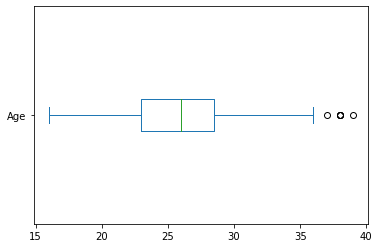

In [5]:
fltr = df[(df['Team'] == 'Canada') & (df['Year'] == 2014)]
fltr['Age'].plot(kind = 'box', vert = False)

<AxesSubplot:>

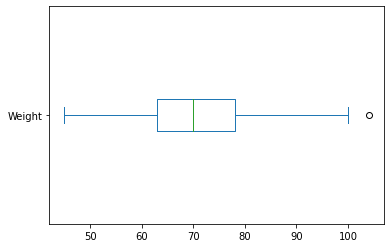

In [6]:
fltr['Weight'].plot(kind = 'box', vert = False)

<AxesSubplot:>

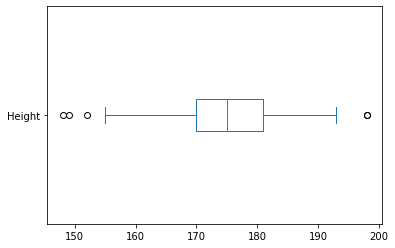

In [7]:
fltr['Height'].plot(kind = 'box', vert = False)

<AxesSubplot:>

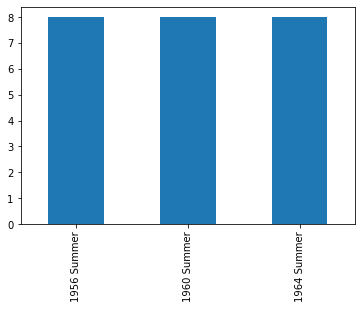

In [10]:
fltr = df[df['Name'] == 'Borys Anfiyanovych Shakhlin']
fltr['Games'].value_counts().plot(kind = 'bar')

<AxesSubplot:>

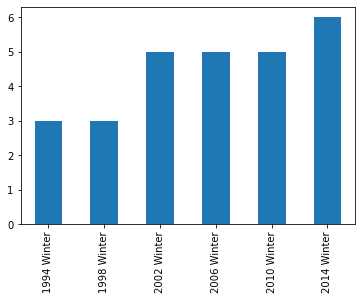

In [14]:
fltr = df[df['Name'] == 'Ole Einar Bjrndalen']
fltr['Games'].value_counts().sort_index().plot(kind = 'bar')

<AxesSubplot:>

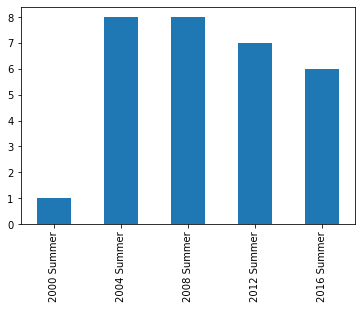

In [15]:
fltr = df[df['Name'] == 'Michael Fred Phelps, II']
fltr['Games'].value_counts().sort_index().plot(kind = 'bar')

<AxesSubplot:>

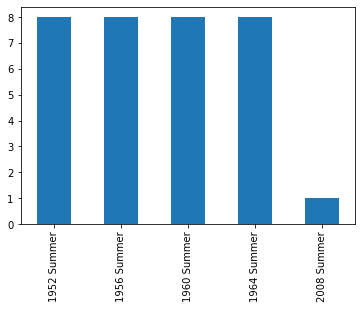

In [18]:
fltr = df[df['Name'] == 'Takashi Ono']
fltr['Games'].value_counts().sort_index().plot(kind = 'bar')

<AxesSubplot:ylabel='Sex'>

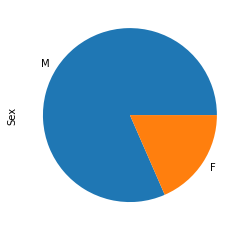

In [20]:
fltr = df[df['Team'] == 'Finland']
fltr['Sex'].value_counts().plot(kind = 'pie')

<AxesSubplot:>

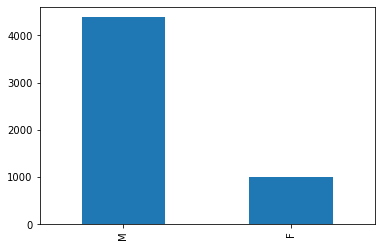

In [21]:
fltr['Sex'].value_counts().plot(kind = 'bar')

<AxesSubplot:>

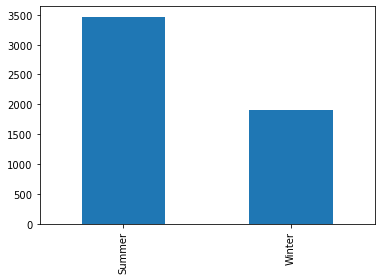

In [22]:
fltr['Season'].value_counts().plot(kind = 'bar')

<AxesSubplot:ylabel='Season'>

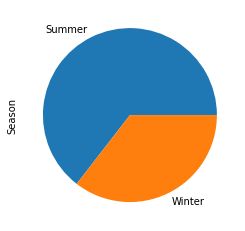

In [23]:
fltr['Season'].value_counts().plot(kind = 'pie')

<AxesSubplot:ylabel='Frequency'>

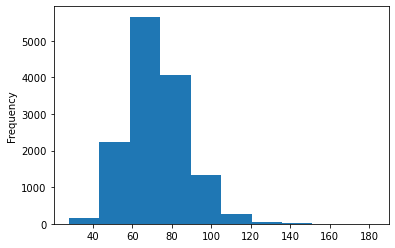

In [26]:
df[df['Team'] == 'United States']['Weight'].plot(kind = 'hist')

<AxesSubplot:xlabel='Weight', ylabel='Height'>

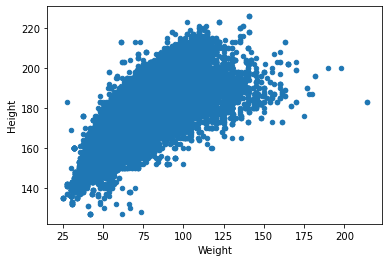

In [27]:
df.plot('Weight', 'Height', kind = 'scatter')

In [35]:
df.groupby('Year')['Age'].mean().idxmin()

1896

In [37]:
df.groupby('Sport')['ID'].nunique().idxmax()

'Athletics'

In [46]:
fltr = df[(df['Medal'] == 'Gold') & 
   (df['Season'] == 'Winter') & 
   (df['Year'] == 1984)]
fltr.groupby('Team')['ID'].nunique().idxmax()

'Soviet Union'

In [ ]:
A
123
444
123
555
666

df['A'].nunique() -> 4
df['A'].unique() -> array([123, 444, 555, 666])

In [49]:
gb = df.groupby('NOC')[['Height', 'Weight']].max()
gb['diff'] = abs(gb['Height'] - gb['Weight'])
gb['diff'].min()

21.0

In [55]:
fltr = df[df['Team'] == 'Soviet Union']
gb = fltr.groupby('ID')[['Event', 'Medal']].count()
gb['rate'] = gb['Medal']/gb['Event']
gb[gb['rate']>=0.5].shape[0]

1453

In [60]:
al = df.groupby('Games')['ID'].nunique()
fem = df[df['Sex'] == 'F'].groupby('Games')['ID'].nunique()
r = fem/al
r[r>r.mean()].shape[0]

24

In [63]:
def medal_weight(x):
    if x == 'Gold':
        return 3
    elif x == 'Silver':
        return 2
    elif x == 'Bronze':
        return 1
    else:
        return 0

In [64]:
df['Medal_score'] = df['Medal'].apply(medal_weight)
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Medal_score
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,3
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,0


In [66]:
df.groupby('Name')['Medal_score'].sum().idxmax()

'Michael Fred Phelps, II'

In [73]:
gb = df.groupby('ID')[['Event', 'Medal']].count()
gb['rate'] = gb['Medal']/gb['Event']
res = gb.merge(df[['ID', 'Team']], left_index = True, right_on = 'ID')
fin = res.groupby('Team')['rate'].mean()
fin[fin == fin.max()].shape[0]

132